# Prompt-Based Generation

In [1]:
import torch
from diffusers import AutoPipelineForText2Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image
import os
from tqdm import tqdm
from pathlib import Path
import shutil
import json

/opt/anaconda3/envs/MSGAIFinal/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/MSGAIFinal/lib/python3.11/site-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


## Data Visualization

### General Information

In [2]:
pd.set_option('display.max_colwidth', None)
data = pd.read_csv("./data/HAM10000_metadata.csv")
data.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [3]:
print(f'{data.shape[0]} samples before dropping patients NaN values')
data = data.dropna()
data = data.reset_index(drop=True)
print(f'{data.shape[0]} samples after dropping patients NaN values')

10015 samples before dropping patients NaN values
9958 samples after dropping patients NaN values


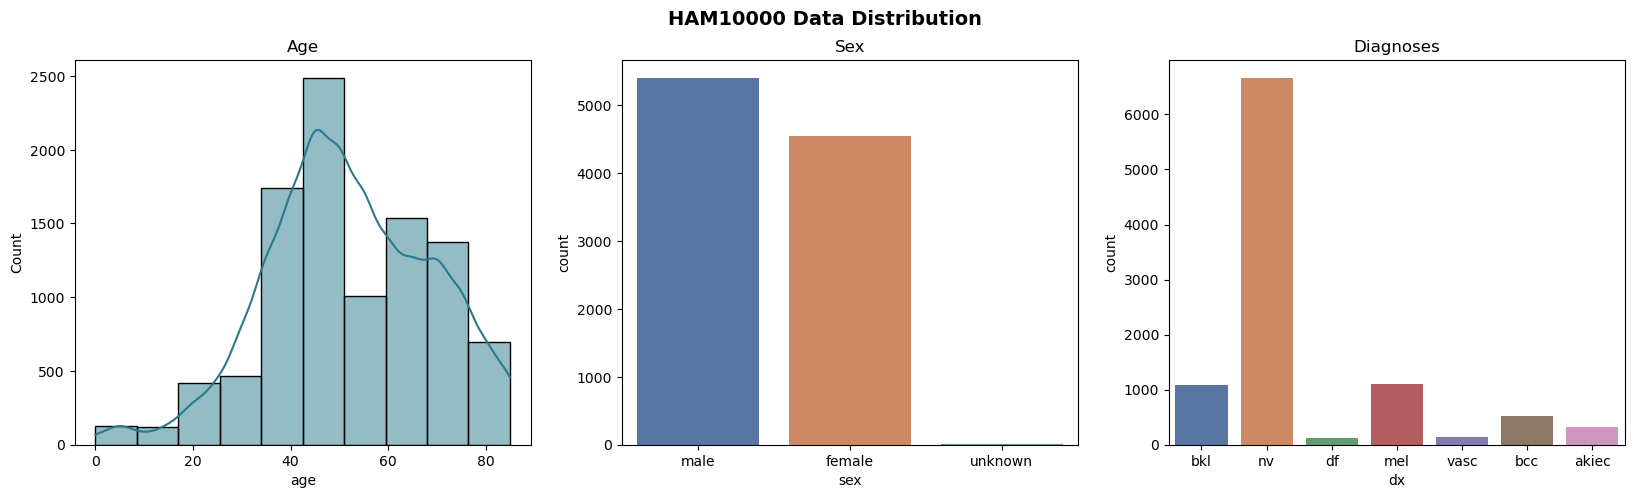

In [4]:
fig, axes = plt.subplots(1,3, figsize=(20,5))

sns.histplot(data=data, bins= 10, x = 'age', kde=True, color=sns.color_palette("crest")[3], ax=axes[0])
axes[0].set_title('Age')

sns.countplot(data=data, x = 'sex', hue='sex', palette='deep', ax=axes[1])
axes[1].set_title("Sex")

sns.countplot(data=data, x = 'dx', palette='deep', hue = 'dx', ax=axes[2])
axes[2].set_title('Diagnoses')

plt.suptitle('HAM10000 Data Distribution', fontweight='bold', fontsize=14)
plt.show()

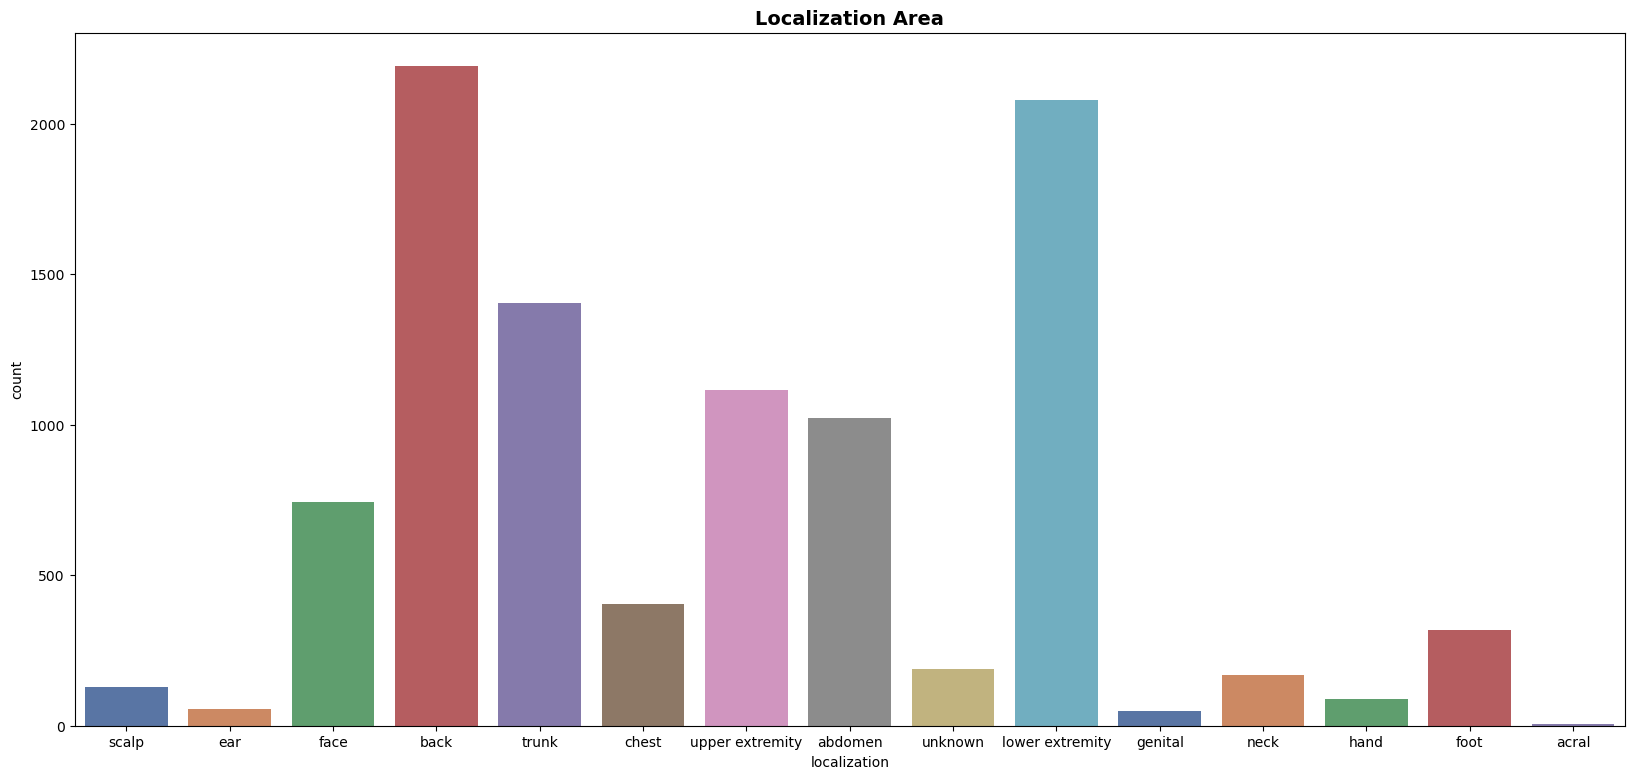

In [5]:
plt.figure(figsize=(20,9))
sns.countplot(data=data, x='localization', palette='deep', hue='localization')
plt.title('Localization Area', fontweight='bold',fontsize=14)
plt.show()

### Display Random Image

In [6]:
index = np.random.randint(0,data.shape[0])

def display_image(index):
    image_id = data['image_id'][index]
    if not image_id.endswith('.jpg'):
        image_id += '.jpg'
    file1 = os.path.join('data', 'HAM10000_images_part_1', image_id)
    file2 = os.path.join('data', 'HAM10000_images_part_2', image_id)
    
    if os.path.exists(file1):
        return file1
    elif os.path.exists(file2):
        return file2
    else:
        raise FileNotFoundError

image = display_image(index)

In [7]:
def display_metadata(index):
    image_metadata = pd.DataFrame(data.iloc[index,:]).reset_index()
    image_metadata.columns = ['Feature', 'Value']
    return image_metadata

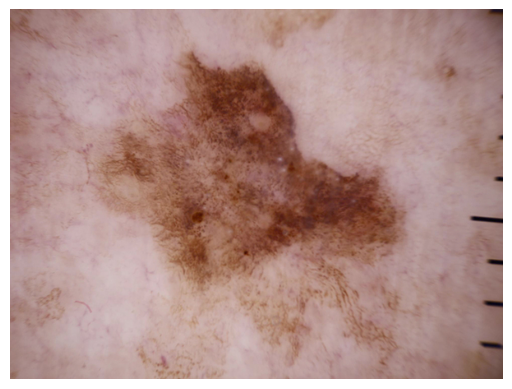

,Feature,Value
0,lesion_id,HAM_0007232
1,image_id,ISIC_0025830
2,dx,bkl
3,dx_type,histo
4,age,80.0
5,sex,male
6,localization,back


In [8]:
image = Image.open(image)
plt.imshow(image)
plt.axis('off')
plt.show()
display_metadata(index)


## Prompt Builder

In [9]:
diagnosis_map = {
    'akiec': 'actinic keratosis / Bowen\'s disease',
    'bcc': 'basal cell carcinoma',
    'bkl': 'benign keratosis-like lesion',
    'df': 'dermatofibroma',
    'mel': 'melanoma',
    'nv': 'melanocytic nevus',
    'vasc': 'vascular lesion'
}

In [10]:
prompts = {
    "full_metadata": [
        "Dermoscopy image of a {dx} on the {site} of a {age}-year-old {sex}.",
        "Dermoscopic photograph showing a {dx} on the {site} in a {age}-year-old {sex}.",
        "Skin lesion ({dx}) located on the {site} of a {age}-year-old {sex}.",
        "Dermoscopy of a {dx} on the {site} in a {age}-year-old {sex}.",
        "Cutaneous {dx} located on the {site} of a {age}-year-old {sex}, dermoscopy image.",
        "Dermoscopic close-up showing a {dx} on the {site} of a {age}-year-old {sex}.",
        "Pigmented lesion ({dx}) on the {site} in a {age}-year-old {sex}, dermoscopic view."
    ],

    "no_sex": [
        "High-resolution dermoscopy of a {dx} on the {site}.",
        "Clinical dermoscopic view of a {dx} on the {site}.",
        "Dermoscopic image presenting a {dx} on the {site}.",
        "Magnified skin image of a {dx} found on the {site}.",
        "Detailed dermoscopy of a {dx} lesion on the {site}.",
        "Macro dermoscopic photograph depicting a {dx} on the {site}.",
        "Skin surface dermoscopy showing a {dx} on the {site}.",
        "Dermoscopic evaluation image of a {dx} on the {site}.",
        "Standardized dermoscopy photograph of a {dx} on the {site}.",
        "Polarized dermoscopy image of a {dx} on the {site}.",
        "Clinical close-up dermoscopy showing {dx} on the {site}.",
        "{dx} on the {site}, dermoscopy image.",
        "Dermoscopic photo: {dx} on the {site}.",
        "Dermoscopy view of lesion: {dx} on {site}.",
        "Magnified dermoscopy image of {dx} on the {site}."
    ],

    "no_localization": [
        "Diagnostic dermoscopy capture depicting a {dx}.",
        "Dermatology-focused dermoscopic image showing a {dx} lesion.",
        "Dermoscopy of {dx}.",
        "High-quality dermoscopic image of a {dx}.",
        "Clinical dermoscopic capture showing {dx}."
    ],

    "dx_only": [
        "Dermoscopic image of a {dx}.",
        "Skin lesion consistent with {dx}, dermoscopy view.",
        "Close-up dermoscopic capture revealing {dx}.",
        "Dermatology image showing features of {dx}.",
        "Dermoscopy photograph displaying {dx}."
    ]
}

In [11]:
def create_prompt(df_row):
    if df_row['localization'] == 'unknown' and df_row['sex'] == 'unknown':
        prompt_choice = np.random.choice(prompts['dx_only'])
    elif df_row['localization'] == 'unknown':
        prompt_choice = np.random.choice(prompts['no_localization'])
    elif df_row['sex'] == 'unknown':
        prompt_choice = np.random.choice(prompts['no_sex'])
    else:
        categories = ['full_metadata', 'no_sex', 'no_localization', 'dx_only']
        selected_category = np.random.choice(categories, p=[0.7,0.1,0.1,0.1])
        prompt_choice = np.random.choice(prompts[selected_category])
        
    
    if 'dx' in prompt_choice:
        diagnoses = df_row['dx']
        mapping = diagnosis_map[diagnoses]
        prompt_choice = prompt_choice.replace('{dx}', mapping)
    if 'site' in prompt_choice:
        prompt_choice = prompt_choice.replace('{site}', df_row['localization'])
    if 'age' in prompt_choice:
        prompt_choice = prompt_choice.replace('{age}', str(int(df_row['age'])))
    if 'sex' in prompt_choice:
        prompt_choice = prompt_choice.replace('{sex}', df_row['sex'])
    
    return prompt_choice

In [12]:
row, col = data.shape
data['Prompt'] = np.full((row), 'NA')

for idx in range(row):
    patient = data.iloc[idx,:]
    prompt = create_prompt(patient)
    data.loc[idx, 'Prompt'] = prompt
    
data.head(10)

,lesion_id,image_id,dx,dx_type,age,sex,localization,Prompt
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,Dermoscopy image of a benign keratosis-like lesion on the scalp of a 80-year-old male.
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,Clinical dermoscopic capture showing benign keratosis-like lesion.
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,Dermoscopy image of a benign keratosis-like lesion on the scalp of a 80-year-old male.
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,Dermoscopic photograph showing a benign keratosis-like lesion on the scalp in a 80-year-old male.
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,Dermoscopic photograph showing a benign keratosis-like lesion on the ear in a 75-year-old male.
5,HAM_0001466,ISIC_0027850,bkl,histo,75.0,male,ear,Polarized dermoscopy image of a benign keratosis-like lesion on the ear.
6,HAM_0002761,ISIC_0029176,bkl,histo,60.0,male,face,Dermoscopic image of a benign keratosis-like lesion.
7,HAM_0002761,ISIC_0029068,bkl,histo,60.0,male,face,Detailed dermoscopy of a benign keratosis-like lesion lesion on the face.
8,HAM_0005132,ISIC_0025837,bkl,histo,70.0,female,back,"Pigmented lesion (benign keratosis-like lesion) on the back in a 70-year-old female, dermoscopic view."
9,HAM_0005132,ISIC_0025209,bkl,histo,70.0,female,back,Skin lesion (benign keratosis-like lesion) located on the back of a 70-year-old female.


,Feature,Value
0,lesion_id,HAM_0007232
1,image_id,ISIC_0025830
2,dx,bkl
3,dx_type,histo
4,age,80.0
5,sex,male
6,localization,back
7,Prompt,"Pigmented lesion (benign keratosis-like lesion) on the back in a 80-year-old male, dermoscopic view."


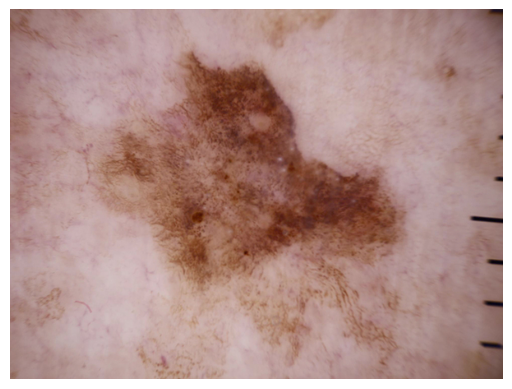

In [13]:
image = display_image(index)
image = Image.open(image)
plt.imshow(image)
plt.axis('off')
display_metadata(index)

## Stable Diffusion

In [14]:
device = (
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)

Creating a unified folder with the desired input structure for stable diffusion fine-tuning

In [ ]:
src1 = Path("data/HAM10000_images_part_1")
src2 = Path("data/HAM10000_images_part_2")
dst  = Path("data/ham_lora")

dst.mkdir(parents=True, exist_ok=True)

for p in list(src1.glob("*.jpg")) + list(src2.glob("*.jpg")):
    target = dst / p.name
    if not target.exists():
        shutil.copy2(p, target)

len(list(dst.glob("*.jpg")))

10015

In [ ]:
meta_path = dst / "metadata.jsonl"

rows = 0
with open(meta_path, "w") as f:
    for _, row in data.iterrows():
        image_id = row["image_id"]
        if not image_id.endswith(".jpg"):
            image_id += ".jpg"

        img_path = dst / image_id
        if not img_path.exists():
            continue

        prompt = row["Prompt"]

        f.write(json.dumps({"file_name": image_id, "text": prompt}) + "\n")
        rows += 1

print("Wrote", rows, "rows to metadata.jsonl")

Wrote 9958 rows to metadata.jsonl


## Inference

In [ ]:
pipeline_base = AutoPipelineForText2Image.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to(device)

prompt = "Dermoscopy image of a melanoma on the upper back of a 65-year-old male."

out = pipeline_base(prompt, num_inference_steps=30, guidance_scale=7.5)
image_base = out.images[0]

In [ ]:
pipeline = AutoPipelineForText2Image.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to(device)

pipeline.load_lora_weights(
    "lora-ham10000-500 samples",
    weight_name="pytorch_lora_weights.safetensors"
)

for _ in tqdm(range(1)):
    prompt = "Dermoscopy image of a melanoma on the upper back of a 65-year-old male."
    image = pipeline(prompt, num_inference_steps=30, guidance_scale=7.5).images[0]

Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  5.00it/s]
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
100%|██████████| 1/1 [00:18<00:00, 18.35s/it]


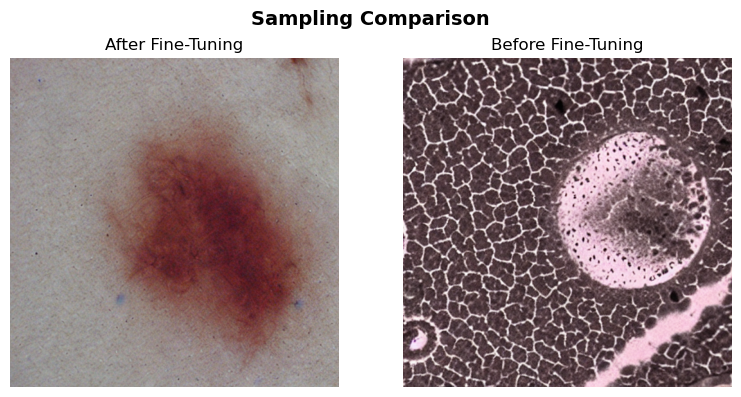

In [26]:
fig, axes = plt.subplots(1,2, figsize=(8,4))
axes[0].imshow(image)
axes[0].set_title('After Fine-Tuning')
axes[0].axis('off')
axes[1].imshow(image_base)
axes[1].set_title('Before Fine-Tuning')
axes[1].axis('off')
plt.suptitle('Sampling Comparison', fontweight = 'bold', fontsize=14)
plt.tight_layout()
plt.show()